### Error Handling

In [ ]:
# setting the environment variables, the keys
import sys
import os

sys.path.insert(0, os.path.abspath('..'))
# import config
from config import set_environment
from set_agents import get_agent
set_environment()

First, we can add `try... except ...` block to handle errors within your Python functions that are called by your chain or represent graph nodes:

In [ ]:
from enum import Enum
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

class IsSuitableJobEnum(str, Enum):
    YES = "YES"
    NO = "NO"

prompt_template = PromptTemplate.from_template(
    "Given a job description, decide whether it suits a junior Java developer.\n"
    "JOB DESCRIPTION:\n{job_description}\n\n"
    "Answer ONLY one token: YES or NO."
)

llm = get_agent("googleadc")
chain = prompt_template | llm | StrOutputParser()

raw = chain.invoke({"job_description": "test job description"}).strip().upper()
result = IsSuitableJobEnum(raw)  # raises if not YES/NO
print(result.value)


In [ ]:
# Option 2 using Pydantic
from typing import Literal
from pydantic import BaseModel
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser

class Suitability(BaseModel):
    suitable: Literal["YES", "NO"]

parser = PydanticOutputParser(pydantic_object=Suitability)

prompt = PromptTemplate.from_template(
    "Decide whether this job suits a junior Java developer.\n"
    "JOB DESCRIPTION:\n{job_description}\n\n"
    "{format_instructions}"
).partial(format_instructions=parser.get_format_instructions())

llm = get_agent("googleadc")
chain = prompt | llm | parser

result = chain.invoke({"job_description": "test job description"})
print(result.suitable)


In [ ]:
import logging
logger = logging.getLogger(__name__)

job_description =  "test job description"
def analyze_job_description(state):
    try:
      prompt = prompt_template.format(job_description=job_description)
      result = chain.invoke(prompt)
      return {"is_suitable": result}
    except Exception as e:
      logger.error(f"Exception {e} occured while executing analyze_job_description")
      return {"is_suitable": False}

Let's create a fake LLM to test our chain:

In [ ]:
from langchain_core.language_models import GenericFakeChatModel
from langchain_core.messages import AIMessage

class MessagesIterator:

    def __init__(self):
        self._count = 0

    def __iter__(self):
        return self

    def __next__(self):
        self._count += 1
        if self._count % 2 == 1:
            raise ValueError("Something went wrong")
        return AIMessage(content="YES")

fake_llm = GenericFakeChatModel(messages=MessagesIterator())

In [ ]:
print(fake_llm)

Let's reuse the graph from our previous notebook:

In [ ]:
from typing_extensions import TypedDict
from typing import Annotated, Literal
from operator import add
from langgraph.graph import StateGraph, START, END

class JobApplicationState(TypedDict):
    job_description: str
    is_suitable: bool
    application: str
    actions: Annotated[list[str], add]

def generate_application(state):
    print("...generating application...")
    return {"application": "some_fake_application", "actions": ["action2"]}

def is_suitable_condition(state: JobApplicationState) -> Literal["generate_application", END]:
    if state.get("is_suitable"):
        return "generate_application"
    return END


In [ ]:
from langchain_core.runnables.config import RunnableConfig

llms = {
    "fake": fake_llm,
    "Google": llm
}
job_description =  "test job description"

def analyze_job_description(state, config: RunnableConfig):
    try:
      print("here")
      llm = config["configurable"].get("model_provider", "Google")
      analyze_chain = llm | parser
      prompt = prompt_template.format(job_description=job_description)
      result = analyze_chain.invoke(prompt)
      return {"is_suitable": result}
    except Exception as e:
      logger.error(f"Exception {e} occured while executing analyze_job_description")
      return {"is_suitable": False}

builder = StateGraph(JobApplicationState)
builder.add_node("analyze_job_description", analyze_job_description)
builder.add_node("generate_application", generate_application)
builder.add_edge(START, "analyze_job_description")
builder.add_conditional_edges(
    "analyze_job_description", is_suitable_condition)
    # {
    #     True: "generate_application",
    #     False: END
    # })
builder.add_edge("generate_application", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [ ]:
res = graph.invoke({"job_description":"fake_jd"}, config={"configurable": {"model_provider": "fake"}})
print(res)

In [ ]:
analyze_chain_fake = fake_llm | parser

fake_llm_retry = fake_llm.with_retry(
    retry_if_exception_type=(ValueError,),
    wait_exponential_jitter=True,
    stop_after_attempt=2,
)
analyze_chain_fake_retries = fake_llm_retry | parser

In [ ]:
analyze_chain_fake_retries = (fake_llm | parser).with_retry(
    retry_if_exception_type=(ValueError,),
    wait_exponential_jitter=True,
    stop_after_attempt=2,
)

In [ ]:
analyze_chain_fake_retries.invoke("test")

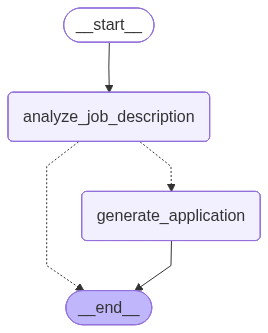

In [30]:
# from langgraph.pregel import RetryPolicy
from langgraph.types import RetryPolicy

def analyze_job_description(state, config: RunnableConfig):
    model_provider = config["configurable"].get("model_provider", "Google")
    llm = llms[model_provider]
    analyze_chain = llm | parser
    prompt = prompt_template.format(job_description=job_description)
    result = analyze_chain.invoke(prompt)
    return {"is_suitable": result}

builder = StateGraph(JobApplicationState)
builder.add_node("analyze_job_description", analyze_job_description, retry=RetryPolicy(retry_on=ValueError, max_attempts=2))
builder.add_node("generate_application", generate_application)
builder.add_edge(START, "analyze_job_description")
builder.add_conditional_edges(
    "analyze_job_description", is_suitable_condition)
builder.add_edge("generate_application", END)

graph = builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [31]:
res = graph.invoke({"job_description": job_description}, config={"configurable": {"model_provider": "fake"}})
print(res)

OutputParserException: Invalid json output: YES
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE 

In [32]:
res = graph.invoke({"job_description":"fake_jd"}, config={"configurable": {"model_provider": "fake"}})
print(res)

OutputParserException: Invalid json output: YES
For troubleshooting, visit: https://docs.langchain.com/oss/python/langchain/errors/OUTPUT_PARSING_FAILURE 

In [33]:
fake_llm.invoke("test")

ValueError: Something went wrong

In [34]:
from langchain_core.runnables import RunnableLambda

chain_fallback = RunnableLambda(lambda _: print("running fallback"))
chain = fake_llm | RunnableLambda(lambda _: print("running main chain"))
chain_with_fb = chain.with_fallbacks([chain_fallback])

chain_with_fb.invoke("test")
chain_with_fb.invoke("test")

running main chain
running fallback
